## Model Selection using RFE (Housing Case Study)

### Importing and Understanding Data

In [1]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import numpy as np

In [3]:
# Importing Housing.csv
housing = pd.read_csv('Housing.csv')

In [4]:
# Looking at the first five rows
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [5]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
housing.nunique()

price               219
area                284
bedrooms              6
bathrooms             4
stories               4
mainroad              2
guestroom             2
basement              2
hotwaterheating       2
airconditioning       2
parking               4
prefarea              2
furnishingstatus      3
dtype: int64

### Data Preparation

In [4]:
# List of variables to map

varlist =  ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# Defining the map function
def binary_map(x):
    return x.map({'yes': 1, "no": 0})

# Applying the function to the housing list
housing[varlist] = housing[varlist].apply(binary_map)

In [8]:
# Check the housing dataframe now

housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


### Dummy Variables

In [ ]:
housing['furnishingstatus'].unique()

The variable `furnishingstatus` has three levels. We need to convert these levels into integer as well. For this, we will use something called `dummy variables`.

In [ ]:
# Get the dummy variables for the feature 'furnishingstatus' and store it in a new variable - 'status'

status = pd.get_dummies(housing['furnishingstatus'])

# Check what the dataset 'status' looks like
status.head()

Now, you don't need three columns. You can drop the `furnished` column, as the type of furnishing can be identified with just the last two columns where — 
- `00` will correspond to `furnished`
- `01` will correspond to `unfurnished`
- `10` will correspond to `semi-furnished`

In [5]:
# Let's drop the first column from status df using 'drop_first = True'
status = pd.get_dummies(housing['furnishingstatus'], drop_first = True)

# Add the results to the original housing dataframe
housing = pd.concat([housing, status], axis = 1)

# Now let's see the head of our dataframe.
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished,False,False


In [6]:
# Drop 'furnishingstatus' as we have created the dummies for it
housing.drop(["furnishingstatus"], axis = 1,inplace = True)
housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


## Splitting the Data into Training and Testing Sets

In [66]:
from sklearn.model_selection import train_test_split

# We specify this so that the train and test data set always have the same rows, respectively

df_train, df_test = train_test_split(housing, train_size = 0.7, test_size = 0.3, random_state = 1969)

In [67]:
df_train.shape

(381, 14)

In [68]:
df_test.shape

(164, 14)

### Rescaling the Features 

We will use MinMax scaling.

<Axes: >

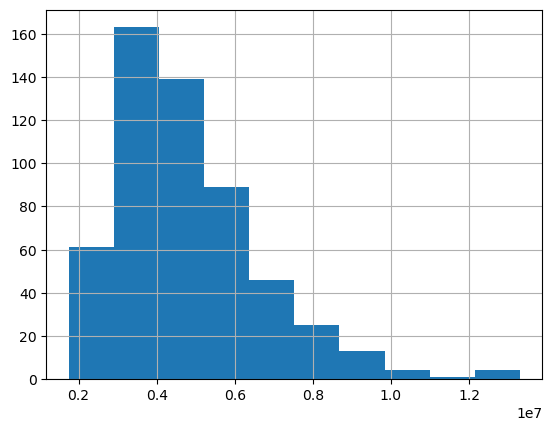

In [14]:
housing.price.hist()

{'whiskers': [<matplotlib.lines.Line2D at 0x23f79330cd0>,
 'caps': [<matplotlib.lines.Line2D at 0x23f79bdaa10>,
 'boxes': [<matplotlib.lines.Line2D at 0x23f79353c50>],
 'medians': [<matplotlib.lines.Line2D at 0x23f79bec0d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x23f792d4b90>],
 'means': []}

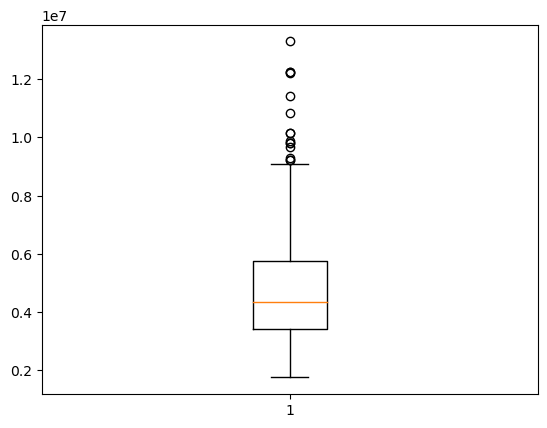

In [15]:
import matplotlib.pyplot as plt
plt.boxplot(housing.price)

<Axes: >

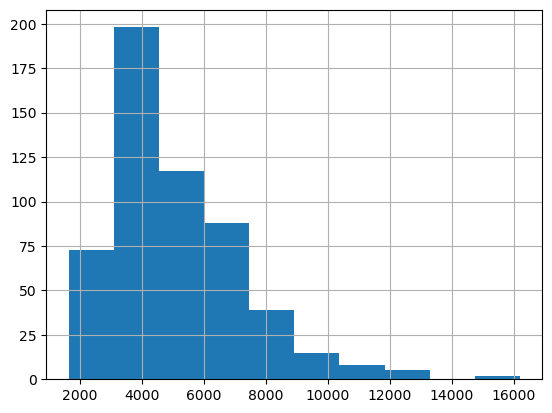

In [16]:
housing.area.hist()

{'whiskers': [<matplotlib.lines.Line2D at 0x23f79cde790>,
 'caps': [<matplotlib.lines.Line2D at 0x23f79cdfe90>,
 'boxes': [<matplotlib.lines.Line2D at 0x23f79cd1dd0>],
 'medians': [<matplotlib.lines.Line2D at 0x23f79ce9390>],
 'fliers': [<matplotlib.lines.Line2D at 0x23f79c87990>],
 'means': []}

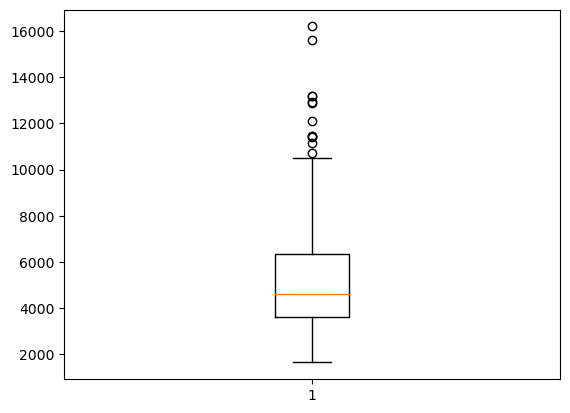

In [17]:
plt.boxplot(housing.area)

In [70]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [71]:
# Apply scaler() to all the columns except the 'yes-no' and 'dummy' variables
num_vars = ['area', 'price']

df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

df_train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
414,0.144848,0.164261,2,1,1,1,0,0,0,0,0,0,False,True
378,0.163636,0.042955,3,1,3,1,0,0,1,1,0,1,True,False
280,0.218182,0.323711,2,1,2,1,0,0,0,0,0,0,False,True
167,0.306061,0.202749,2,2,1,1,0,0,0,1,2,0,True,False
405,0.148485,0.096907,3,1,1,1,0,0,0,0,0,0,False,True


In [69]:
df_train.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
414,3423000,4040,2,1,1,1,0,0,0,0,0,0,False,True
378,3640000,2275,3,1,3,1,0,0,1,1,0,1,True,False
280,4270000,6360,2,1,2,1,0,0,0,0,0,0,False,True
167,5285000,4600,2,2,1,1,0,0,0,1,2,0,True,False
405,3465000,3060,3,1,1,1,0,0,0,0,0,0,False,True


In [ ]:
plt.boxplot(df_train.price)

### Dividing into X and Y sets for the model building

In [12]:
y_train = df_train.pop('price')
X_train = df_train
y_train.head()

414    0.144848
378    0.163636
280    0.218182
167    0.306061
405    0.148485
Name: price, dtype: float64

In [21]:
X_train.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
414,0.164261,2,1,1,1,0,0,0,0,0,0,False,True
378,0.042955,3,1,3,1,0,0,1,1,0,1,True,False
280,0.323711,2,1,2,1,0,0,0,0,0,0,False,True
167,0.202749,2,2,1,1,0,0,0,1,2,0,True,False
405,0.096907,3,1,1,1,0,0,0,0,0,0,False,True


In [ ]:
plt.boxplot(X_train.area)

In [55]:
X_train.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
414,0.164261,2,1,1,1,0,0,0,0,0,0,0,1
378,0.042955,3,1,3,1,0,0,1,1,0,1,1,0
280,0.323711,2,1,2,1,0,0,0,0,0,0,0,1
167,0.202749,2,2,1,1,0,0,0,1,2,0,1,0
405,0.096907,3,1,1,1,0,0,0,0,0,0,0,1


## Building our model

This time, we will be using the **LinearRegression function from SciKit Learn** for its compatibility with RFE (which is a utility from sklearn)

### RFE
## Recursive feature elimination

In [22]:
# Importing RFE and LinearRegression
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

In [23]:
# Running RFE with the output number of the variable equal to 10
lm = LinearRegression()
lm.fit(X_train, y_train)
print(lm)

LinearRegression()


In [24]:
print(list(zip(X_train.columns, lm.coef_)))

[('area', 0.32577850511689194), ('bedrooms', 0.015752108150724798), ('bathrooms', 0.08213007289831645), ('stories', 0.03515157297567676), ('mainroad', 0.04924300880771397), ('guestroom', 0.029665618442512955), ('basement', 0.022436630424722145), ('hotwaterheating', 0.09121882722403991), ('airconditioning', 0.07818892129920224), ('parking', 0.02147619457058535), ('prefarea', 0.05032009084913464), ('semi-furnished', -0.003147809737258168), ('unfurnished', -0.034597797086848445)]


In [25]:
rfe = RFE(lm, n_features_to_select = 10)             # running RFE
rfe

RFE(estimator=LinearRegression(), n_features_to_select=10)

In [26]:
rfe = rfe.fit(X_train, y_train)

In [27]:
list(zip(X_train.columns,rfe.support_,rfe.ranking_))

[('area', True, 1),
 ('bedrooms', False, 3),
 ('bathrooms', True, 1),
 ('stories', True, 1),
 ('mainroad', True, 1),
 ('guestroom', True, 1),
 ('basement', True, 1),
 ('hotwaterheating', True, 1),
 ('airconditioning', True, 1),
 ('parking', False, 2),
 ('prefarea', True, 1),
 ('semi-furnished', False, 4),
 ('unfurnished', True, 1)]

In [28]:
col = X_train.columns[rfe.support_]
col

Index(['area', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement',
       'hotwaterheating', 'airconditioning', 'prefarea', 'unfurnished'],
      dtype='object')

In [29]:
X_train.columns[~rfe.support_]

Index(['bedrooms', 'parking', 'semi-furnished'], dtype='object')

In [33]:
r2 = rfe.score(X_train, y_train)
r2

0.652927603188118

In [41]:
from sklearn.metrics import mean_squared_error
y_pred = rfe.predict(X_train)
y_pred[0:5]

array([0.10224904, 0.4016745 , 0.20139068, 0.32548197, 0.07722521])

In [40]:
y_train.head()

414    0.144848
378    0.163636
280    0.218182
167    0.306061
405    0.148485
Name: price, dtype: float64

In [42]:
rmse = np.sqrt(mean_squared_error(y_train, y_pred))
rmse

0.09559136014193353

In [43]:
num_vars = ['area', 'price']

df_test[num_vars] = scaler.transform(df_test[num_vars])

df_test.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
62,0.460606,0.315464,4,2,2,1,0,0,0,1,1,0,False,False
187,0.290909,0.305842,3,1,1,1,0,1,0,1,0,1,True,False
487,0.096970,0.257732,4,1,2,1,0,0,0,0,0,0,False,True
508,0.072727,0.189003,2,1,1,1,0,0,0,0,0,0,False,True
371,0.163636,0.131959,3,1,2,1,0,1,0,0,0,0,True,False


In [44]:
y_test = df_test.pop('price')
X_test = df_test
y_test.head()

62     0.460606
187    0.290909
487    0.096970
508    0.072727
371    0.163636
Name: price, dtype: float64

In [45]:
# from sklearn.metrics import mean_squared_error
y_pred_test = rfe.predict(X_test)
y_pred_test[0:5]

array([0.40726014, 0.35070906, 0.17687754, 0.11144147, 0.19594272])

In [46]:
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
rmse_test

0.0894976253691796

### Building model using statsmodel, for the detailed statistics

In [13]:
X_train.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
414,0.164261,2,1,1,1,0,0,0,0,0,0,False,True
378,0.042955,3,1,3,1,0,0,1,1,0,1,True,False
280,0.323711,2,1,2,1,0,0,0,0,0,0,False,True
167,0.202749,2,2,1,1,0,0,0,1,2,0,True,False
405,0.096907,3,1,1,1,0,0,0,0,0,0,False,True


In [14]:
X_train['semi-furnished']=X_train['semi-furnished'].replace(to_replace = True, value =1)

In [15]:
X_train['unfurnished']=X_train['unfurnished'].replace(to_replace = True, value =1)

In [16]:
X_train['semi-furnished']=X_train['semi-furnished'].replace(to_replace = False, value =0)

In [17]:
X_train['unfurnished']=X_train['unfurnished'].replace(to_replace = False, value =0)

In [19]:
X_train.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
414,0.164261,2,1,1,1,0,0,0,0,0,0,0,1
378,0.042955,3,1,3,1,0,0,1,1,0,1,1,0
280,0.323711,2,1,2,1,0,0,0,0,0,0,0,1
167,0.202749,2,2,1,1,0,0,0,1,2,0,1,0
405,0.096907,3,1,1,1,0,0,0,0,0,0,0,1


In [78]:
# Adding a constant variable 
import statsmodels.api as sm  
X_train_1 = sm.add_constant(X_train)

In [79]:
X_train_1.head()

,const,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
414,1.0,0.164261,2,1,1,1,0,0,0,0,0,0,0,1
378,1.0,0.042955,3,1,3,1,0,0,1,1,0,1,1,0
280,1.0,0.323711,2,1,2,1,0,0,0,0,0,0,0,1
167,1.0,0.202749,2,2,1,1,0,0,0,1,2,0,1,0
405,1.0,0.096907,3,1,1,1,0,0,0,0,0,0,0,1


In [58]:
lm_1 = sm.OLS(y_train,X_train_1).fit()   # Running the linear model

In [59]:
#Let's see the summary of our linear model
print(lm_1.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                     56.82
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.53e-79
Time:                        18:16:21   Log-Likelihood:                 362.36
No. Observations:                 381   AIC:                            -696.7
Df Residuals:                     367   BIC:                            -641.5
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.1297      0.027     

`Bedrooms` is insignificant in presence of other variables; can be dropped

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
X = X_train_1.drop(['const'], axis = 1)
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,bedrooms,17.06
2,bathrooms,9.39
3,stories,7.85
4,mainroad,7.23
0,area,4.94
11,semi-furnished,2.56
12,unfurnished,2.09
6,basement,2.07
9,parking,1.97
8,airconditioning,1.82


In [80]:
X_train_2 = X_train_1.drop(["semi-furnished"], axis = 1)
X_train_2.head()

,const,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished
414,1.0,0.164261,2,1,1,1,0,0,0,0,0,0,1
378,1.0,0.042955,3,1,3,1,0,0,1,1,0,1,0
280,1.0,0.323711,2,1,2,1,0,0,0,0,0,0,1
167,1.0,0.202749,2,2,1,1,0,0,0,1,2,0,0
405,1.0,0.096907,3,1,1,1,0,0,0,0,0,0,1


In [62]:
lm_2 = sm.OLS(y_train,X_train_2).fit()   # Running the linear model

In [63]:
#Let's see the summary of our linear model
print(lm_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     61.71
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.96e-80
Time:                        18:25:24   Log-Likelihood:                 362.32
No. Observations:                 381   AIC:                            -698.6
Df Residuals:                     368   BIC:                            -647.4
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.1323      0.025     

### Check VIF

In [64]:
vif = pd.DataFrame()
X = X_train_2.drop(['const'], axis = 1)
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,bedrooms,16.17
2,bathrooms,9.29
3,stories,7.85
4,mainroad,6.98
0,area,4.94
6,basement,2.07
9,parking,1.97
8,airconditioning,1.79
5,guestroom,1.53
10,prefarea,1.46


In [81]:
X_train_3 = X_train_2.drop(["bedrooms"], axis = 1)

In [66]:
lm_3 = sm.OLS(y_train,X_train_3).fit() 

In [67]:
#Let's see the summary of our linear model
print(lm_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.654
Method:                 Least Squares   F-statistic:                     66.41
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           1.69e-80
Time:                        18:27:19   Log-Likelihood:                 360.25
No. Observations:                 381   AIC:                            -696.5
Df Residuals:                     369   BIC:                            -649.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.1033      0.021     

In [68]:
vif = pd.DataFrame()
X = X_train_3.drop(['const'], axis = 1)
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
1,bathrooms,7.29
3,mainroad,6.55
2,stories,6.01
0,area,4.79
8,parking,1.97
5,basement,1.89
7,airconditioning,1.78
4,guestroom,1.52
9,prefarea,1.46
10,unfurnished,1.42


In [82]:
X_train_4 = X_train_3.drop(["bathrooms"], axis = 1)

In [25]:
lm_4 = sm.OLS(y_train,X_train_4).fit() 

In [26]:
#Let's see the summary of our linear model
print(lm_4.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     56.73
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.45e-68
Time:                        13:52:23   Log-Likelihood:                 329.33
No. Observations:                 381   AIC:                            -636.7
Df Residuals:                     370   BIC:                            -593.3
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0283      0.020     

In [29]:
vif = pd.DataFrame()
X = X_train_4.drop(['const'], axis = 1)
vif['Features'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
2,mainroad,6.21
0,area,4.53
1,stories,4.49
7,parking,1.96
4,basement,1.80
6,airconditioning,1.78
3,guestroom,1.52
8,prefarea,1.46
9,unfurnished,1.40
5,hotwaterheating,1.10


## Residual Analysis of the train data

So, now to check if the error terms are also normally distributed (which is infact, one of the major assumptions of linear regression), let us plot the histogram of the error terms and see what it looks like.

In [30]:
y_train.head()

414    0.144848
378    0.163636
280    0.218182
167    0.306061
405    0.148485
Name: price, dtype: float64

In [31]:
y_train_pred = lm_4.predict(X_train_4)

In [32]:
y_train_pred.head()

414    0.090395
378    0.427015
280    0.205954
167    0.268419
405    0.065097
dtype: float64

In [33]:
# Importing the required libraries for plots.
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Text(0.5, 0, 'Errors')

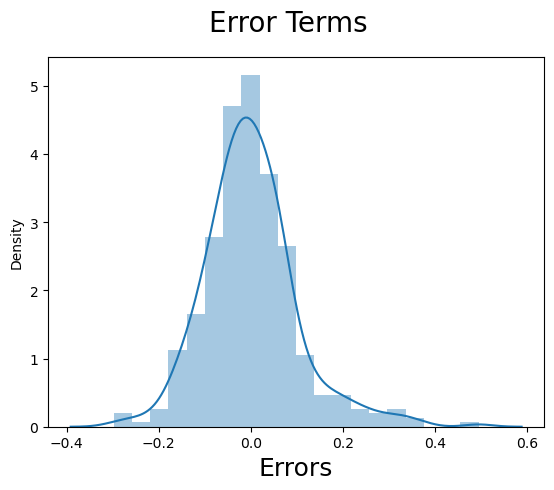

In [34]:
# Plot the histogram of the error terms
fig = plt.figure()
sns.distplot((y_train - y_train_pred), bins = 20)
fig.suptitle('Error Terms', fontsize = 20)                  # Plot heading 
plt.xlabel('Errors', fontsize = 18)                         # X-label

In [35]:
(y_train - y_train_pred).skew()

0.8398107670376642

In [ ]:
plt.scatter(df_train.index, (y_train - y_train_pred))
plt.suptitle('Pattern of Error Terms', fontsize = 20)  
plt.xlabel('Observations', fontsize = 18) 
plt.ylabel("Residuals", fontsize = 18)
plt.axhline(y=0.0, color='r', linestyle='-')
# plt.savefig("Pattern of Error Term")

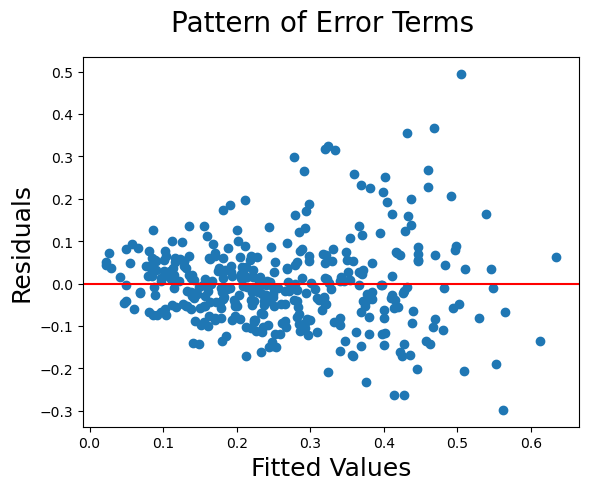

In [36]:
plt.scatter(y_train_pred, (y_train - y_train_pred))
plt.suptitle('Pattern of Error Terms', fontsize = 20)  
plt.xlabel('Fitted Values', fontsize = 18) 
plt.ylabel("Residuals", fontsize = 18)
plt.axhline(y=0.0, color='r', linestyle='-')
# plt.savefig("Pattern of Error Term")

**Residual vs Fitted Graph**
First up is the Residuals vs Fitted plot. This graph shows if there are any nonlinear patterns in the residuals, and thus in the data as well. One of the mathematical assumptions in building an OLS model is that the data can be fit by a line. If this assumption holds and our data can be fit by a linear model, then we should see a relatively flat line when looking at the residuals vs fitted.

In [37]:
# create dataframe from X, y for easier plot handling
dataframe = pd.concat([X_train_4.drop(['const'], axis = 1), y_train], axis=1)
dataframe.head()

,area,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished,price
414,0.164261,1,1,0,0,0,0,0,0,1,0.144848
378,0.042955,3,1,0,0,1,1,0,1,0,0.163636
280,0.323711,2,1,0,0,0,0,0,0,1,0.218182
167,0.202749,1,1,0,0,0,1,2,0,0,0.306061
405,0.096907,1,1,0,0,0,0,0,0,1,0.148485


In [38]:
# model values
model_fitted_y = lm_4.fittedvalues
model_fitted_y

414    0.090395
378    0.427015
280    0.205954
167    0.268419
405    0.065097
         ...   
124    0.383862
165    0.328455
288    0.284345
228    0.222630
513    0.155358
Length: 381, dtype: float64

In [39]:
# model residuals
model_residuals = lm_4.resid
model_residuals.head()

414    0.054453
378   -0.263379
280    0.012228
167    0.037642
405    0.083388
dtype: float64

In [40]:
# normalized residuals
model_norm_residuals = lm_4.get_influence().resid_studentized_internal
model_norm_residuals

array([ 5.30284186e-01, -2.67029730e+00,  1.19177303e-01,  3.68767370e-01,
        8.12529440e-01, -3.45400802e-01,  1.21213122e-01, -1.35298884e-02,
       -1.35023289e+00, -1.09524355e+00, -1.01025153e+00,  9.14831148e-01,
       -1.81391054e-01,  2.28336329e+00,  7.54893972e-01,  4.27513028e-01,
       -4.06187769e-01,  1.57745660e-01,  9.83265469e-02, -5.05689935e-01,
        2.65054105e-01,  3.46847730e-01, -1.13377856e+00,  4.84868834e+00,
        1.39417348e+00, -1.33649100e+00, -3.53380826e-01, -7.38187219e-02,
       -3.97943892e-01, -5.19053422e-02, -6.70278354e-01,  7.69541390e-01,
        5.33200183e-01, -1.45082516e+00,  5.31088156e-01,  1.68771273e+00,
       -3.47846923e-01, -4.69280622e-01, -1.08500160e+00,  1.58835813e+00,
        6.76997314e-01,  2.60563495e+00,  6.13137509e-02,  2.05796235e-01,
        5.72634890e-01, -9.37547213e-02,  6.26456407e-01,  1.50404448e-01,
        1.04349869e+00,  4.07017444e-01, -4.09403439e-01,  1.54691084e-01,
       -1.02664267e+00, -

In [41]:
# normalized residuals
model_norm_residuals = lm_4.get_influence().resid_studentized_internal

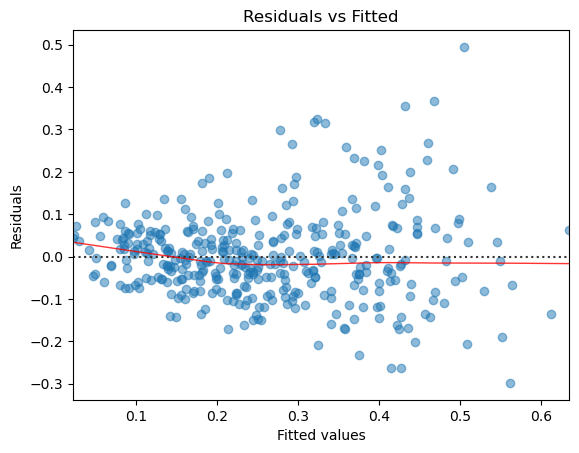

In [42]:
# create dataframe from X, y for easier plot handling
dataframe = pd.concat([X_train_4.drop(['const'], axis = 1), y_train], axis=1)
# model values
model_fitted_y = lm_4.fittedvalues
# model residuals
model_residuals = lm_4.resid
# normalized residuals
model_norm_residuals = lm_4.get_influence().resid_studentized_internal
# absolute squared normalized residuals
model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))
# absolute residuals
model_abs_resid = np.abs(model_residuals)
# leverage, from statsmodels internals
model_leverage = lm_4.get_influence().hat_matrix_diag
# cook's distance, from statsmodels internals
model_cooks = lm_4.get_influence().cooks_distance[0]

plot3_lm_4 = plt.figure()
plot3_lm_4.axes[0] = sns.residplot(x=model_fitted_y, y=dataframe.columns[-1], data=dataframe,
                          lowess=True,
                          scatter_kws={'alpha': 0.5},
                          line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})

plot3_lm_4.axes[0].set_title('Residuals vs Fitted')
plot3_lm_4.axes[0].set_xlabel('Fitted values')
plot3_lm_4.axes[0].set_ylabel('Residuals');

In [48]:
dataframe.columns

Index(['area', 'stories', 'mainroad', 'guestroom', 'basement',
       'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'unfurnished', 'price'],
      dtype='object')

In [50]:
dataframe.corr()

,area,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished,price
area,1.000000,0.066486,0.299881,0.175657,0.057046,-0.008474,0.255422,0.354771,0.209346,-0.138277,0.551383
stories,0.066486,1.000000,0.116515,0.067068,-0.175853,0.023952,0.291041,0.036453,0.052694,-0.043651,0.398779
mainroad,0.299881,0.116515,1.000000,0.107346,0.042797,-0.044635,0.125463,0.218647,0.175036,-0.158326,0.321583
guestroom,0.175657,0.067068,0.107346,1.000000,0.371764,-0.000690,0.172402,0.049828,0.156789,-0.078010,0.288325
basement,0.057046,-0.175853,0.042797,0.371764,1.000000,0.034723,0.021788,0.038659,0.193865,-0.092943,0.161206
hotwaterheating,-0.008474,0.023952,-0.044635,-0.000690,0.034723,1.000000,-0.139008,0.046181,-0.078977,-0.050042,0.121240
airconditioning,0.255422,0.291041,0.125463,0.172402,0.021788,-0.139008,1.000000,0.150327,0.146479,-0.063584,0.445670
parking,0.354771,0.036453,0.218647,0.049828,0.038659,0.046181,0.150327,1.000000,0.052944,-0.166227,0.354358
prefarea,0.209346,0.052694,0.175036,0.156789,0.193865,-0.078977,0.146479,0.052944,1.000000,-0.064357,0.306966
unfurnished,-0.138277,-0.043651,-0.158326,-0.078010,-0.092943,-0.050042,-0.063584,-0.166227,-0.064357,1.000000,-0.250423


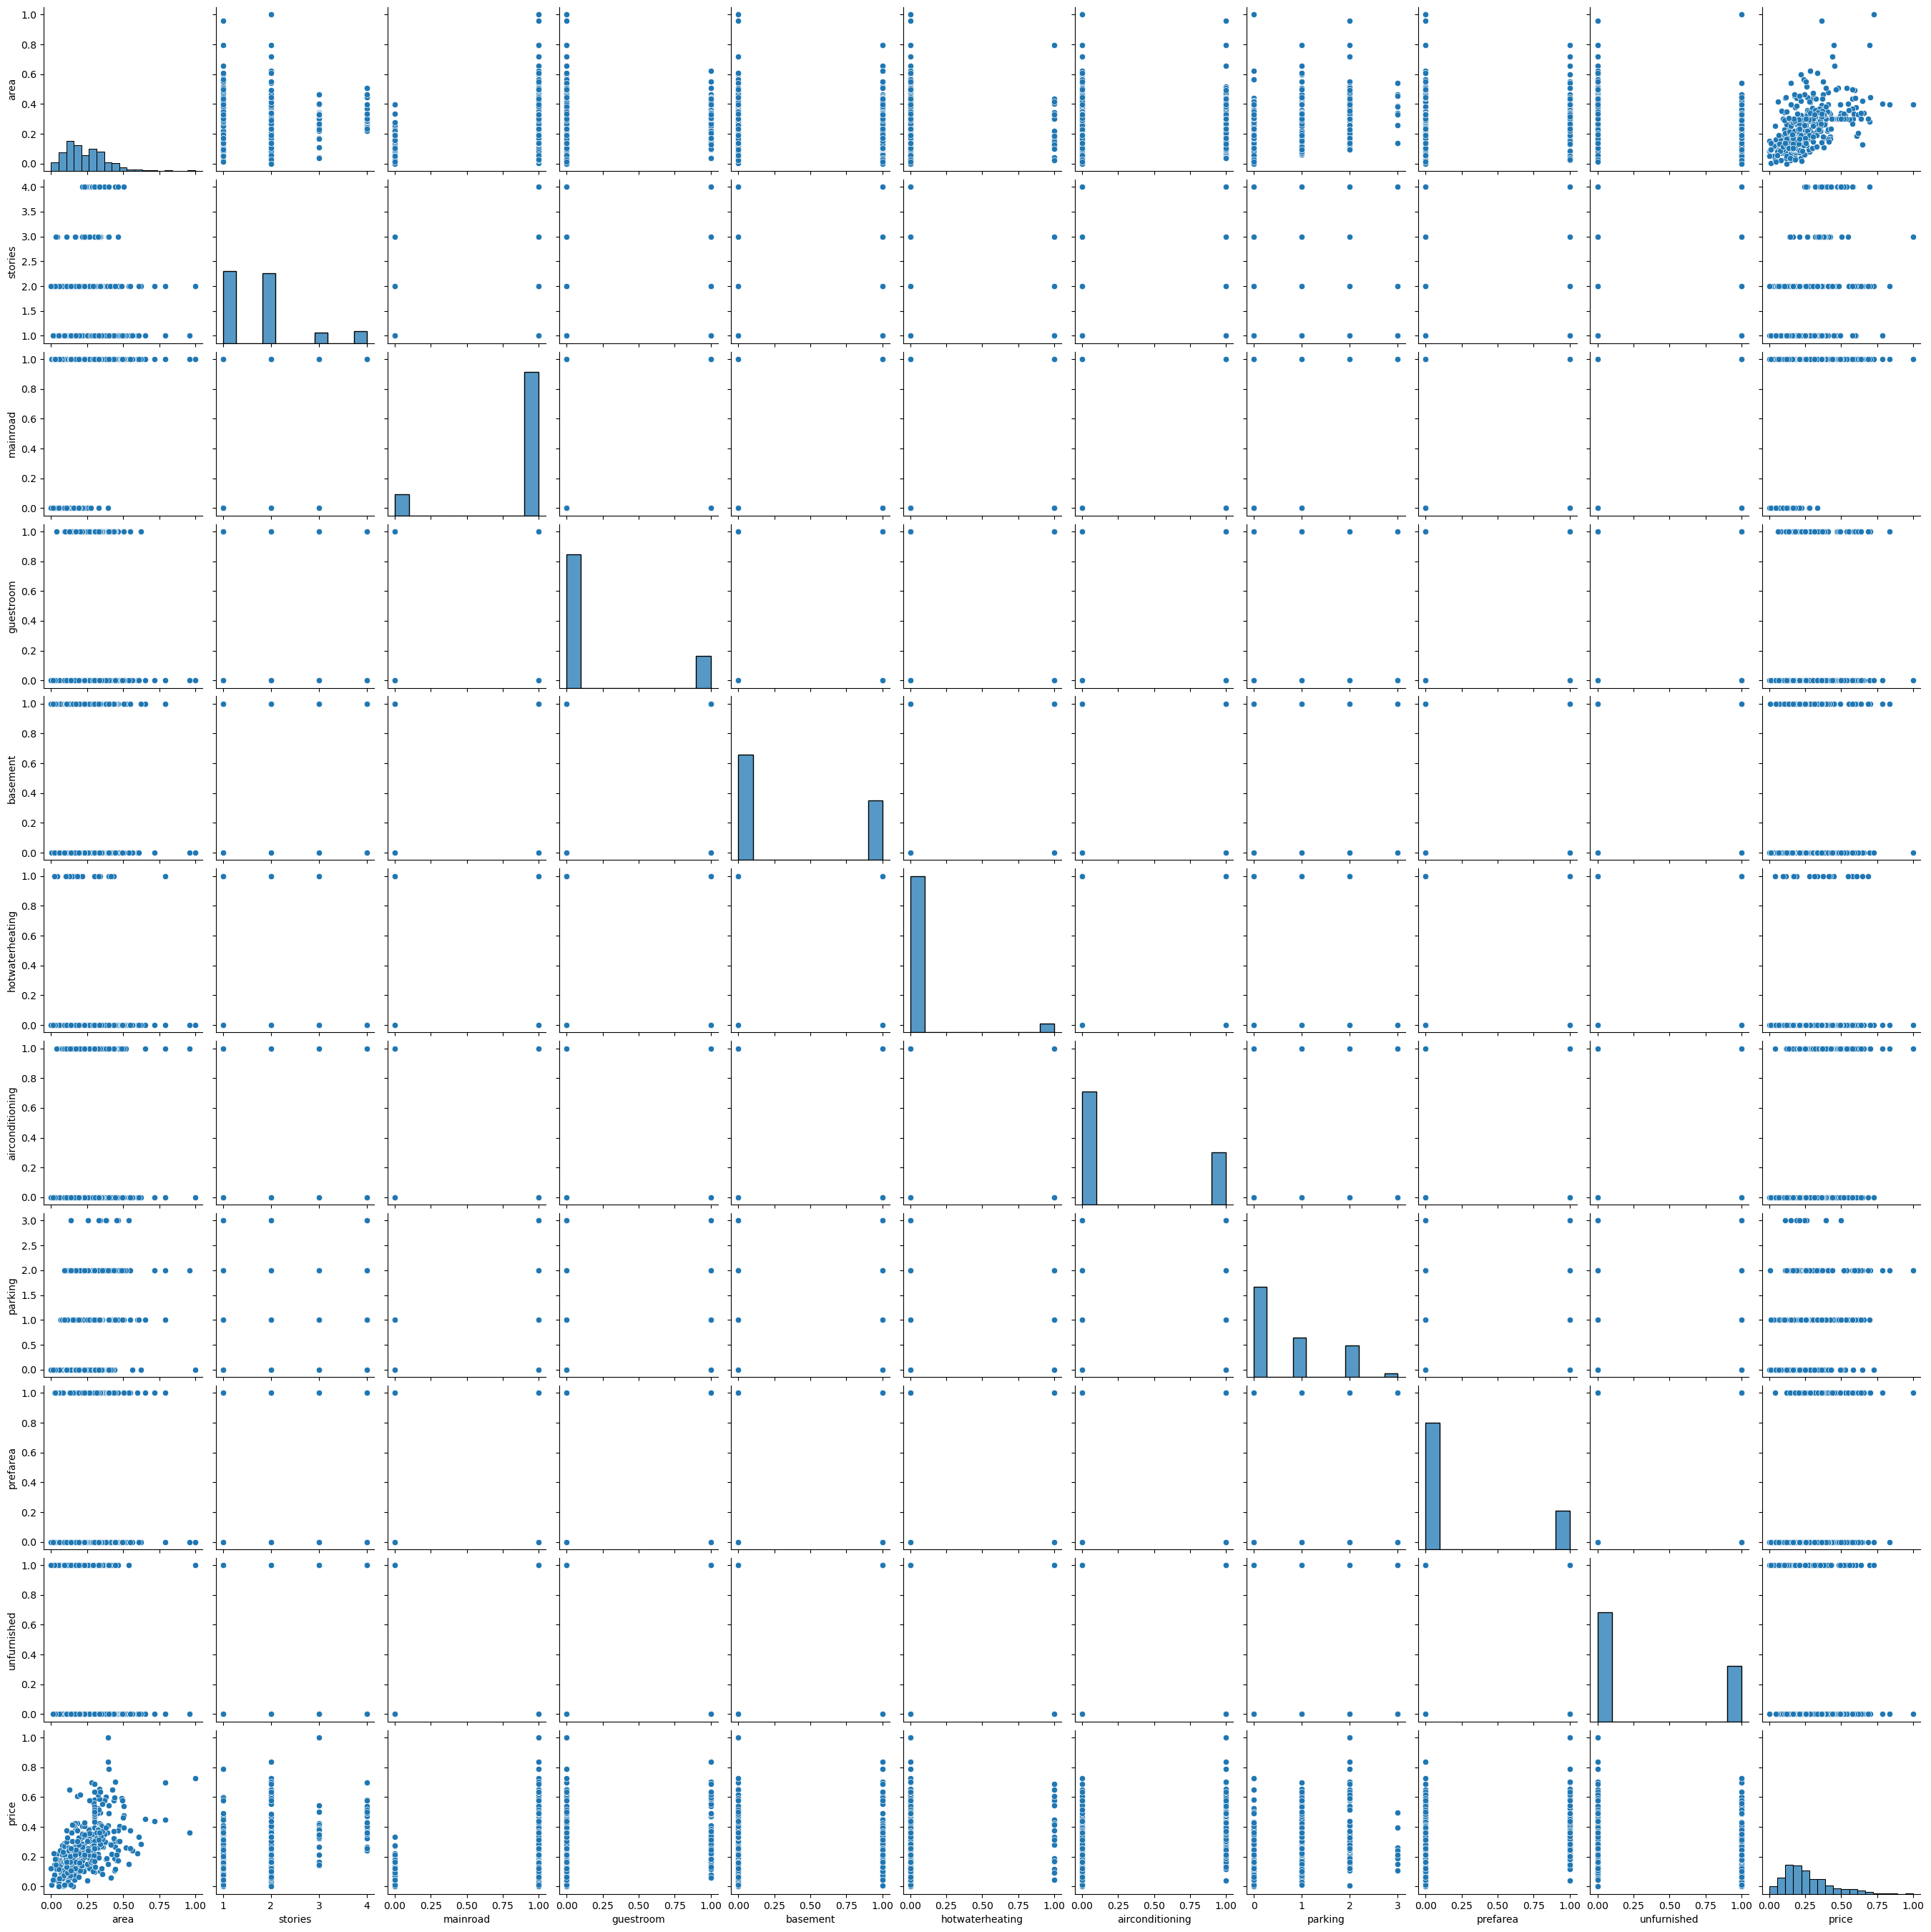

In [51]:
sns.pairplot(dataframe)

In [52]:
X_train_4["area2"] = X_train_4["area"]*X_train["area"]

In [53]:
X_train_4.head()

,const,area,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished,area2
414,1.0,0.164261,1,1,0,0,0,0,0,0,1,0.026982
378,1.0,0.042955,3,1,0,0,1,1,0,1,0,0.001845
280,1.0,0.323711,2,1,0,0,0,0,0,0,1,0.104789
167,1.0,0.202749,1,1,0,0,0,1,2,0,0,0.041107
405,1.0,0.096907,1,1,0,0,0,0,0,0,1,0.009391


In [54]:
lm_5 = sm.OLS(y_train,X_train_4).fit() 

In [55]:
lm_5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  price   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     51.77
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           5.50e-68
Time:                        14:11:10   Log-Likelihood:                 330.08
No. Observations:                 381   AIC:                            -636.2
Df Residuals:                     369   BIC:                            -588.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.0388      0.022     -1.756      0.080      -0.082       0.005
area                0.4962      0.108      4.589      0.000       0.284       0.709
stories             0.0554      0.007      8.338      0.000       0.042       0.068
mainroad            0.0353      0.017      2.041      0.042       0.001       0.069
guestroom           0.0319      0.015      2.095      0.037       0.002       0.062
basement            0.0370      0.012      2.980      0.003       0.013       0.061
hotwaterheating     0.1050      0.024      4.431      0.000       0.058       0.152
airconditioning     0.0745      0.013      5.859      0.000       0.049       0.100
parking             0.0240      0.007      3.553      0.000       0.011       0.037
prefarea            0.0520      0.013      3.924      0.000       0.026       0.078
unfurnished        -0.0374      0.012     -3.240      0.001      -0.060      -0.015
area2              -0.1666      0.138     -1.206      0.228      -0.438       0.105
==============================================================================
Omnibus:                       64.828   Durbin-Watson:                   2.029
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              149.909
Skew:                           0.861   Prob(JB):                     2.80e-33
Kurtosis:                       5.545   Cond. No.                         82.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

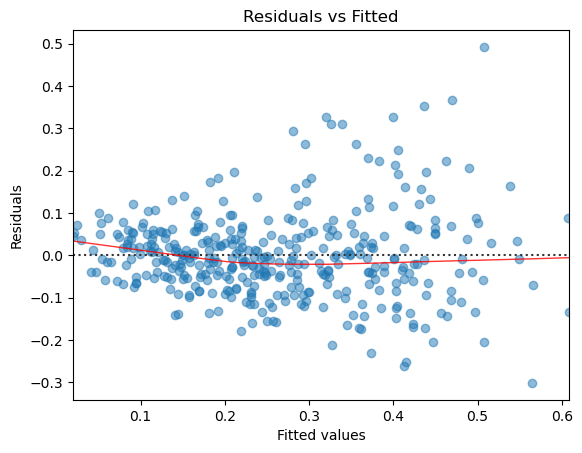

In [56]:
# create dataframe from X, y for easier plot handling
dataframe = pd.concat([X_train_4.drop(['const'], axis = 1), y_train], axis=1)
# model values
model_fitted_y = lm_5.fittedvalues
# model residuals
model_residuals = lm_5.resid
# normalized residuals
model_norm_residuals = lm_5.get_influence().resid_studentized_internal
# absolute squared normalized residuals
model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))
# absolute residuals
model_abs_resid = np.abs(model_residuals)
# leverage, from statsmodels internals
model_leverage = lm_5.get_influence().hat_matrix_diag
# cook's distance, from statsmodels internals
model_cooks = lm_5.get_influence().cooks_distance[0]

plot3_lm_4 = plt.figure()
plot3_lm_4.axes[0] = sns.residplot(x=model_fitted_y, y=dataframe.columns[-1], data=dataframe,
                          lowess=True,
                          scatter_kws={'alpha': 0.5},
                          line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})

plot3_lm_4.axes[0].set_title('Residuals vs Fitted')
plot3_lm_4.axes[0].set_xlabel('Fitted values')
plot3_lm_4.axes[0].set_ylabel('Residuals');

An ideal Residuals vs Fitted plot will look like random noise; there won’t be any apparent patterns in the scatterplot and the red line would be horizontal.

Examine the plot generated using the housing dataset. Notice the bow-shaped line in red? This is an indicator that we are failing to capture some of the non-linear features of the model. In other words, we are underfitting the model. Perhaps the variance in the data might be better captured using the square (or some other non-linear transformation) of one or more of the features.

**Normal Q-Q Plot**
This plot shows if the residuals are normally distributed. A good normal QQ plot has all of the residuals lying on or close to the red line. This one shows how well the distribution of residuals fit the normal distribution. This plots the standardized (z-score) residuals against the theoretical normal quantiles. Anything quite off the diagonal lines may be a concern for further investigation. For this, I’m using ProbPlot and its qqplot method from statsmodels graphics API. statsmodels actually has a qqplot method that we can use directly, but it’s not very customizable, hence this two-step approach. Annotations were a bit tricky, as theoretical quantiles from ProbPlot are already sorted:

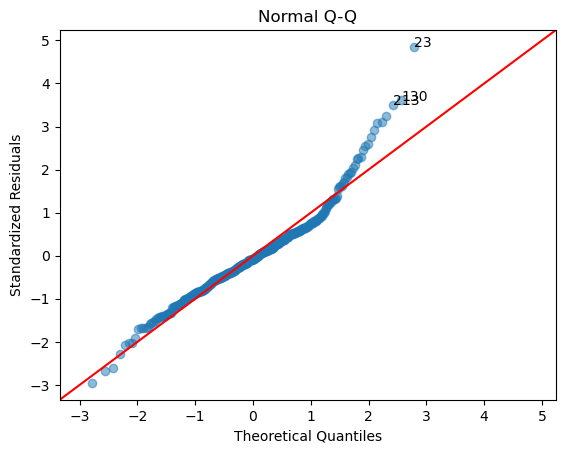

In [43]:
from statsmodels.graphics.gofplots import ProbPlot
QQ = ProbPlot(model_norm_residuals)
plot4_lm_3 = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
plot4_lm_3.axes[0].set_title('Normal Q-Q')
plot4_lm_3.axes[0].set_xlabel('Theoretical Quantiles')
plot4_lm_3.axes[0].set_ylabel('Standardized Residuals');
# annotations
abs_norm_resid = np.flip(np.argsort(np.abs(model_norm_residuals)), 0)
abs_norm_resid_top_3 = abs_norm_resid[:3]
for r, i in enumerate(abs_norm_resid_top_3):
    plot4_lm_3.axes[0].annotate(i,
                               xy=(np.flip(QQ.theoretical_quantiles, 0)[r],
                                   model_norm_residuals[i]));

Looking at the graph above, there are several points that fall far away from the red line. This is indicative of the errors not being normally distributed, in fact our model suffers from “heavy tails”.

What does this say about the data? We are more likely to see extreme values than to be expected if the data was truly normally distributed.

In general, there is plenty of wiggle room in violating these assumptions, but it is good to know what assumptions about the data we are violating.

**Scale-Location**
This is another residual plot to check if the residuals suffer from non-constant variance, aka heteroscedasticity. It’s essentially a scatter plot of absolute square-rooted normalized residuals and fitted values, with a lowess regression line. Scatterplot is a standard matplotlib function, lowess line comes from seaborn regplot. Top 3 absolute square-rooted normalized residuals are also annotated:

KeyError: 23

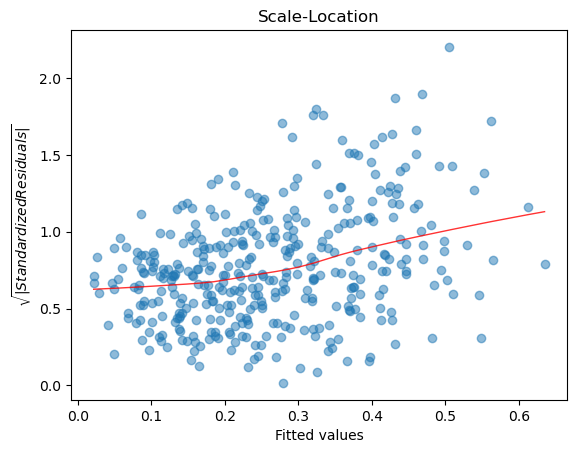

In [44]:
plot5_lm_3 = plt.figure()
plt.scatter(model_fitted_y, model_norm_residuals_abs_sqrt, alpha=0.5);
sns.regplot(x=model_fitted_y, y=model_norm_residuals_abs_sqrt,
              scatter=False,
              ci=False,
              lowess=True,
              line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
plot5_lm_3.axes[0].set_title('Scale-Location')
plot5_lm_3.axes[0].set_xlabel('Fitted values')
plot5_lm_3.axes[0].set_ylabel('$\sqrt{|Standardized Residuals|}$');

# annotations

abs_sq_norm_resid = np.flip(np.argsort(model_norm_residuals_abs_sqrt), 0)
abs_sq_norm_resid_top_3 = abs_sq_norm_resid[:3]
for i in abs_norm_resid_top_3:
      plot5_lm_3.axes[0].annotate(i,
                                 xy=(model_fitted_y[i],
                                     model_norm_residuals_abs_sqrt[i]));

This particular plot (with the housing data) is a tricky one to debug. The more horizontal the red line is, the more likely the data is homoscedastic. While a typical heteroscedastic plot has a sideways “V” shape, our graph has higher values on the left and on the right versus in the middle. This might be caused by not capturing the non-linearities in the model (see Residuals vs Fitted plot) and merits further investigation or model tweaking. The two most common methods of “fixing” heteroscedasticity is using a weighted least squares approach, or using a heteroscedastic-corrected covariance matrix (hccm). Both of these methods are beyond the scope of this post.

**Residuals vs Leverage plot**
Leverage points are nasty buggers. Unlike outliers, which have an unusually large y value, leverage points have extreme x values. This may not seem so bad at face value, but it can have damaging effects on the model because the β coefficients are very sensitive to leverage points. The purpose of the Residuals vs Leverage plot is to identify these problematic observations.

This plot shows if any outliers have influence over the regression fit. Anything outside the group and outside “Cook’s Distance” lines, may have an influential effect on model fit. statsmodels has a built-in leverage plot for linear regression, but again, it’s not very customizable. Digging around the source of the statsmodels.graphics package, it’s pretty straightforward to implement it from scratch and customize with standard matplotlib functions. There are three parts to this plot: First is the scatterplot of leverage values (got from statsmodels fitted model using get_influence().hat_matrix_diag) vs. standardized residuals. Second one is the lowess regression line for that. And the third and the most tricky part is the Cook’s distance lines, which I currently couldn’t figure out how to draw in Python. But statsmodels has Cook’s distance already calculated, so we can use that to annotate top 3 influencers on the plot: Update: I think I figured out how to draw Cook’s distance (D) contours for D = 0.5 and D = 1. The trick was rearranging the formula to plot the lines at 0.5 and 1.

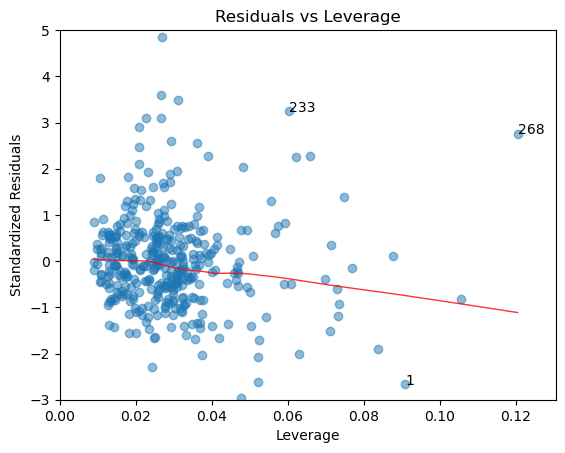

In [45]:
plot6_lm_3 = plt.figure();
plt.scatter(model_leverage, model_norm_residuals, alpha=0.5);
sns.regplot(x=model_leverage, y=model_norm_residuals,
              scatter=False,
              ci=False,
              lowess=True,
              line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});
plot6_lm_3.axes[0].set_xlim(0, max(model_leverage)+0.01)
plot6_lm_3.axes[0].set_ylim(-3, 5)
plot6_lm_3.axes[0].set_title('Residuals vs Leverage')
plot6_lm_3.axes[0].set_xlabel('Leverage')
plot6_lm_3.axes[0].set_ylabel('Standardized Residuals');

  # annotations
leverage_top_3 = np.flip(np.argsort(model_cooks), 0)[:3]
for i in leverage_top_3:
      plot6_lm_3.axes[0].annotate(i,
                                 xy=(model_leverage[i],
                                     model_norm_residuals[i]));

Fortunately, this arguably one of the easiest plots to interpret. Thanks to Cook’s Distance, we only need to find leverage points that have a distance greater than 0.5. In this plot, we do not have any leverage points that meet this criteria.

In practice, there may be cases where we may want to remove points with a Cook’s distance of less than 0.5, especially if there are only a few observations compared to the rest of the data. I would argue that removing the point on the far right of the plot should improve the model. If the point is removed, we would re-run this analysis again and determine how much the model improved.

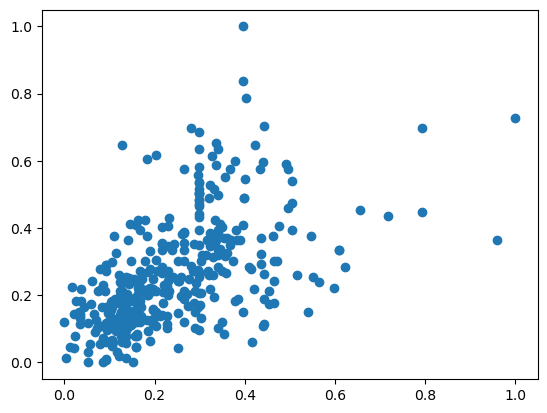

In [57]:
plt.scatter(X_train.area, y_train)

<Axes: xlabel='area', ylabel='price'>

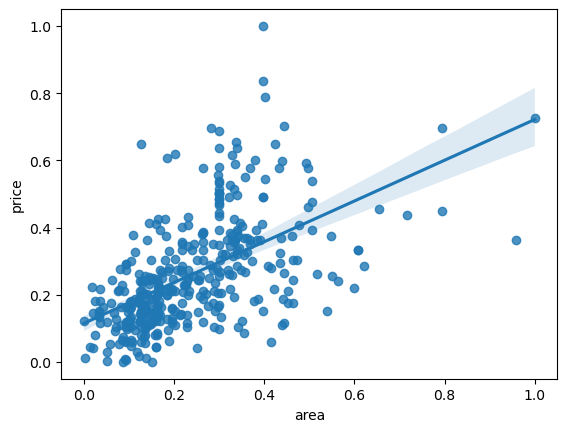

In [58]:
sns.regplot(x=X_train.area, y=y_train)

<Axes: xlabel='stories', ylabel='price'>

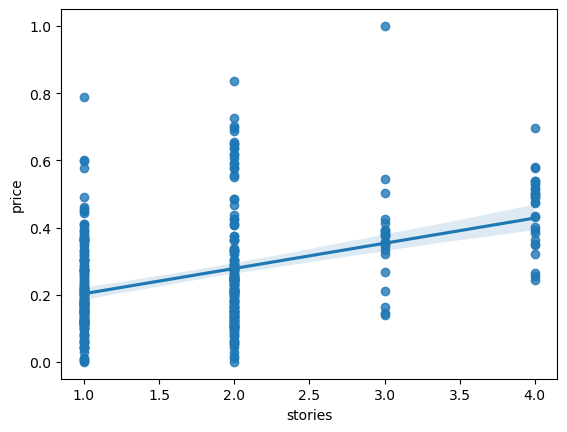

In [59]:
sns.regplot(x=X_train.stories, y=y_train)

## Making Predictions

#### Applying the scaling on the test sets

In [72]:
num_vars = ['area', 'price']

df_test[num_vars] = scaler.transform(df_test[num_vars])

In [73]:
df_test.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
62,0.460606,0.315464,4,2,2,1,0,0,0,1,1,0,False,False
187,0.290909,0.305842,3,1,1,1,0,1,0,1,0,1,True,False
487,0.096970,0.257732,4,1,2,1,0,0,0,0,0,0,False,True
508,0.072727,0.189003,2,1,1,1,0,0,0,0,0,0,False,True
371,0.163636,0.131959,3,1,2,1,0,1,0,0,0,0,True,False


#### Dividing into X_test and y_test

In [74]:
y_test = df_test.pop('price')
X_test = df_test

In [75]:
y_test.head()

62     0.460606
187    0.290909
487    0.096970
508    0.072727
371    0.163636
Name: price, dtype: float64

In [76]:
X_test.head()

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
62,0.315464,4,2,2,1,0,0,0,1,1,0,False,False
187,0.305842,3,1,1,1,0,1,0,1,0,1,True,False
487,0.257732,4,1,2,1,0,0,0,0,0,0,False,True
508,0.189003,2,1,1,1,0,0,0,0,0,0,False,True
371,0.131959,3,1,2,1,0,1,0,0,0,0,True,False


In [92]:
# Now let's use our model to make predictions.

# Adding a constant variable 
X_test_1 = sm.add_constant(X_test)
# Creating X_test_new dataframe by dropping variables from X_test
X_test_new = X_test_1[X_train_4.columns]


In [96]:
X_test_new.head(10)

,const,area,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,unfurnished
62,1.0,0.315464,2,1,0,0,0,1,1,0,0
187,1.0,0.305842,1,1,0,1,0,1,0,1,0
487,1.0,0.257732,2,1,0,0,0,0,0,0,1
508,1.0,0.189003,1,1,0,0,0,0,0,0,1
371,1.0,0.131959,2,1,0,1,0,0,0,0,0
17,1.0,0.470790,4,1,0,0,0,1,2,0,0
426,1.0,0.072165,1,0,0,0,0,0,0,0,0
424,1.0,0.099656,2,0,0,1,0,0,0,0,0
35,1.0,0.367698,4,1,0,0,0,1,2,0,0
58,1.0,0.414433,4,1,1,0,0,1,1,0,0


In [94]:
X_test_new['unfurnished']=X_test_new['unfurnished'].replace(to_replace = True, value =1)

In [95]:
X_test_new['unfurnished']=X_test_new['unfurnished'].replace(to_replace = False, value =0)

In [97]:
# Making predictions
from sklearn.metrics import r2_score
y_pred = lm_4.predict(X_test_new)
r2_score(y_test, y_pred)

0.6388126037633877

## Model Evaluation

Text(0, 0.5, 'y_pred')

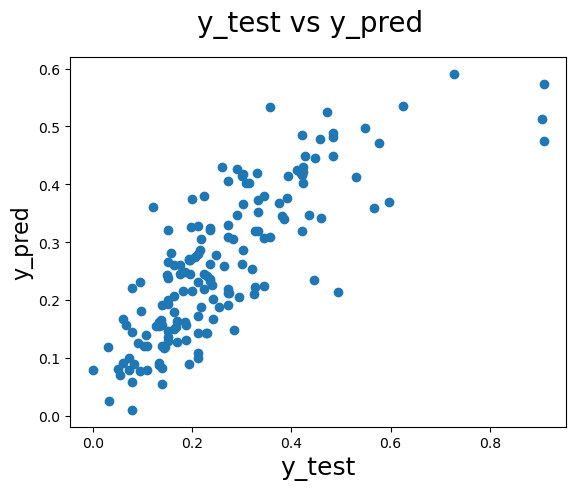

In [98]:
# Plotting y_test and y_pred to understand the spread.
fig = plt.figure()
plt.scatter(y_test,y_pred)
fig.suptitle('y_test vs y_pred', fontsize=20)              # Plot heading 
plt.xlabel('y_test', fontsize=18)                          # X-label
plt.ylabel('y_pred', fontsize=16)                          # Y-label

In [ ]:
import seaborn as sns
sns.pairplot(dataframe, kind="scatter")